# 07 — Advanced CEBRA and dRNN models

I use CEBRA as the main NeuroAI manifold-learning method and a compact recurrent model as a dynamics baseline. Both are optional in compute-heavy environments, but the code is complete and saves fitted artifacts.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


Session: 500855614
Population matrix: (900, 163)
Standardized matrix: (900, 163)
Using device: cpu


pos: -1.0000 neg:  6.3973 total:  5.3973 temperature:  1.0000: 100%|██████████| 2000/2000 [04:35<00:00,  7.27it/s]


CEBRA embedding shape: (900, 3)
Saved standalone CEBRA embedding: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_cebra_embedding.npz
Merged CEBRA into embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_embeddings.npz
Embedding file now contains: ['cebra', 'frame', 'isomap', 'pca', 'pca_full', 'rms_contrast', 'spatial_frequency_centroid', 'umap']
Saved native CEBRA model: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\models\session_500855614_cebra.pt


,session_id,n_frames,embedding_dim,embedding_file,merged_embedding_file,model_file,model_save_status,model_save_error,device,model_architecture,conditional,max_iterations,batch_size,learning_rate,distance
0,500855614,900,3,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,saved,,cpu,offset10-model,time_delta,2000,512,0.001,cosine


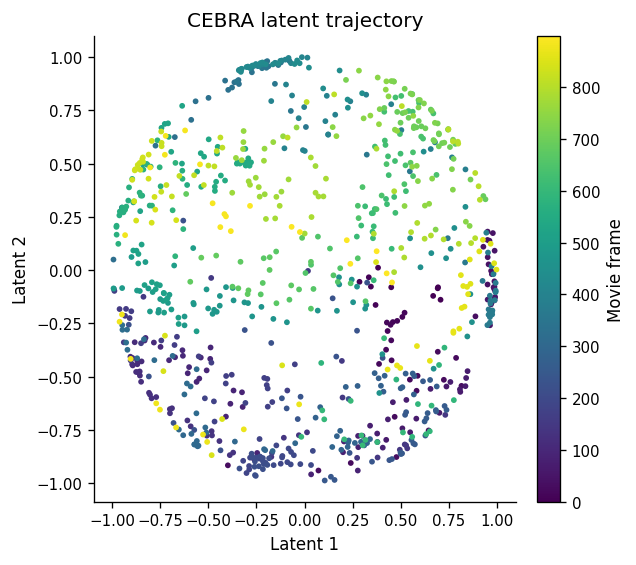

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from v1_manifold.config import select_device
from v1_manifold.preprocessing import load_trial_tensor_h5
from v1_manifold.features import standardize_matrix
from v1_manifold.manifold import fit_cebra_embedding, save_embedding_npz
from v1_manifold.models import TorchDRNN
from v1_manifold.visualization import plot_embedding_2d
from v1_manifold.evaluation import regression_metrics


# ---------------------------------------------------------------------
# Load repeat-averaged V1 population matrix
# ---------------------------------------------------------------------
h5_files = sorted(paths.interim_dir.glob("session_*_tensor.h5"))

if not h5_files:
    raise FileNotFoundError("No trial tensor exists yet. I need to run notebook 03 first.")

tensor_path = h5_files[0]
session_id = tensor_path.name.split("_")[1]

_, R = load_trial_tensor_h5(tensor_path)

# R is frame × cell after loading from the saved tensor.
Xz, _ = standardize_matrix(R)

print("Session:", session_id)
print("Population matrix:", R.shape)
print("Standardized matrix:", Xz.shape)


# ---------------------------------------------------------------------
# Fit CEBRA
# ---------------------------------------------------------------------
device = select_device(cfg["cebra"].get("device", "auto"))
print("Using device:", device)

cebra_labels = np.arange(Xz.shape[0])[:, None]

cebra_z, cebra_model = fit_cebra_embedding(
    Xz,
    labels=cebra_labels,
    output_dimension=cfg["cebra"]["output_dimension"],
    model_architecture=cfg["cebra"]["model_architecture"],
    conditional=cfg["cebra"]["conditional"],
    max_iterations=cfg["cebra"]["max_iterations"],
    batch_size=cfg["cebra"]["batch_size"],
    learning_rate=cfg["cebra"]["learning_rate"],
    distance=cfg["cebra"]["distance"],
    device=device,
    random_state=cfg["project"]["random_seed"],
)

cebra_z = np.asarray(cebra_z, dtype=np.float32)

if cebra_z.ndim != 2:
    raise ValueError(f"Expected CEBRA embedding to be 2D, got shape {cebra_z.shape}.")

if cebra_z.shape[0] != R.shape[0]:
    raise ValueError(
        f"CEBRA/frame mismatch: CEBRA has {cebra_z.shape[0]} rows, "
        f"but R has {R.shape[0]} movie frames."
    )

print("CEBRA embedding shape:", cebra_z.shape)


# ---------------------------------------------------------------------
# Save CEBRA embedding immediately
# ---------------------------------------------------------------------
cebra_embedding_path = paths.processed_dir / f"session_{session_id}_cebra_embedding.npz"

np.savez_compressed(
    cebra_embedding_path,
    cebra=cebra_z,
    frame=np.arange(cebra_z.shape[0]),
)

print(f"Saved standalone CEBRA embedding: {cebra_embedding_path}")


# ---------------------------------------------------------------------
# Merge CEBRA into the existing session embedding file
# ---------------------------------------------------------------------
emb_path = paths.processed_dir / f"session_{session_id}_embeddings.npz"

if emb_path.exists():
    with np.load(emb_path, allow_pickle=False) as old_file:
        old_embeddings = {key: old_file[key] for key in old_file.files}
else:
    old_embeddings = {"frame": np.arange(R.shape[0])}

old_embeddings["cebra"] = cebra_z

save_embedding_npz(emb_path, **old_embeddings)

print(f"Merged CEBRA into embedding file: {emb_path}")
print("Embedding file now contains:", sorted(old_embeddings.keys()))


# ---------------------------------------------------------------------
# Save the CEBRA model using CEBRA's native save method, not joblib
# ---------------------------------------------------------------------
cebra_model_path = paths.models_dir / f"session_{session_id}_cebra.pt"

model_save_status = "not_attempted"
model_save_error = ""

try:
    if hasattr(cebra_model, "save"):
        cebra_model.save(str(cebra_model_path))
        model_save_status = "saved"
        print(f"Saved native CEBRA model: {cebra_model_path}")
    else:
        model_save_status = "skipped_no_native_save_method"
        print("CEBRA model object has no native .save() method. Embedding was saved.")

except Exception as exc:
    model_save_status = "failed"
    model_save_error = str(exc)
    print("WARNING: CEBRA model object could not be saved, but the embedding was saved.")
    print("Model-save error:", model_save_error)


# I save a small metadata table so the report records what happened.
cebra_metadata = pd.DataFrame([
    {
        "session_id": session_id,
        "n_frames": cebra_z.shape[0],
        "embedding_dim": cebra_z.shape[1],
        "embedding_file": str(cebra_embedding_path),
        "merged_embedding_file": str(emb_path),
        "model_file": str(cebra_model_path) if model_save_status == "saved" else "",
        "model_save_status": model_save_status,
        "model_save_error": model_save_error,
        "device": device,
        "model_architecture": cfg["cebra"]["model_architecture"],
        "conditional": cfg["cebra"]["conditional"],
        "max_iterations": cfg["cebra"]["max_iterations"],
        "batch_size": cfg["cebra"]["batch_size"],
        "learning_rate": cfg["cebra"]["learning_rate"],
        "distance": cfg["cebra"]["distance"],
    }
])

save_table(
    cebra_metadata,
    paths.tables_dir / f"07_cebra_metadata_session_{session_id}.csv",
)

display(cebra_metadata)


# ---------------------------------------------------------------------
# Plot CEBRA latent trajectory
# ---------------------------------------------------------------------
fig = plot_embedding_2d(
    cebra_z,
    color=np.arange(cebra_z.shape[0]),
    title="CEBRA latent trajectory",
    colorbar_label="Movie frame",
)

save_figure(
    fig,
    paths.figures_dir / "07_cebra_latent_trajectory.png",
)

plt.show()

Does the CEBRA geometry organize real visual features better than PCA, UMAP, and ISOMAP?

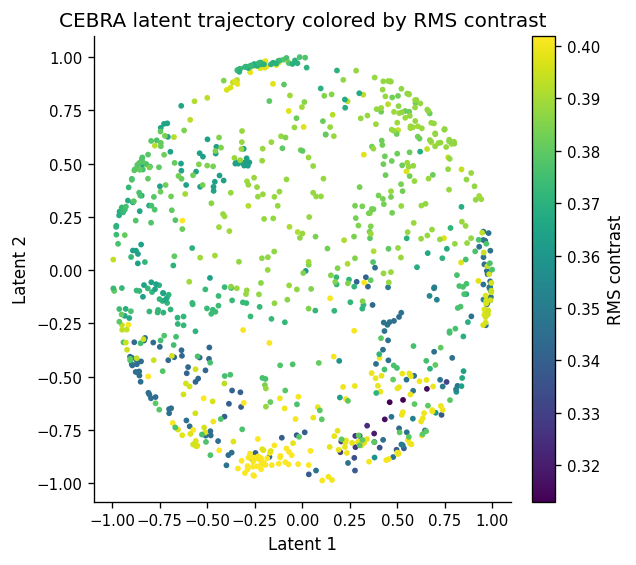

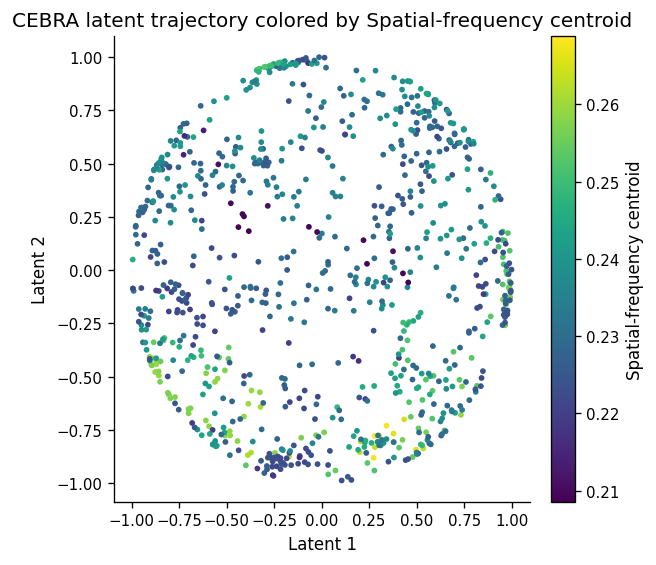

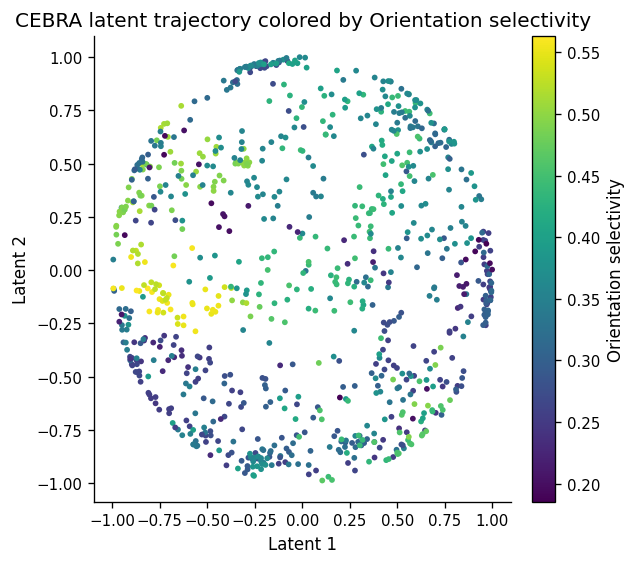

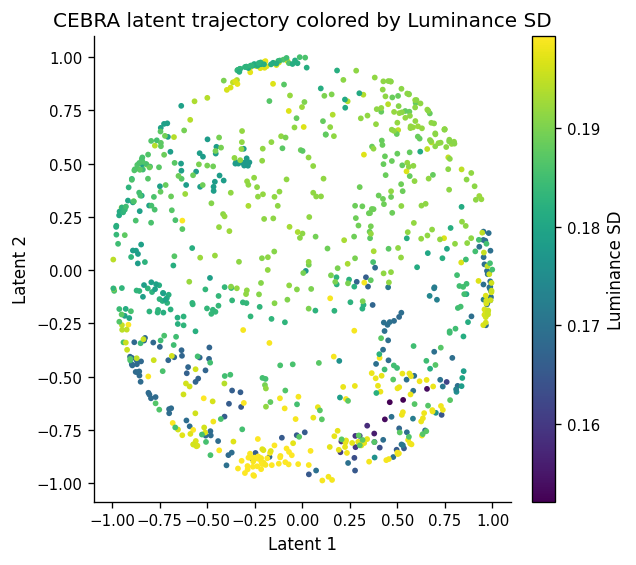

In [4]:
# I visualize CEBRA using real movie-frame features, not only frame index.
feature_candidates = sorted(paths.processed_dir.glob(f"session_{session_id}*_real_frame_features.csv"))
if not feature_candidates:
    feature_candidates = sorted(paths.processed_dir.glob(f"session_{session_id}*_frame_features.csv"))

features = pd.read_csv(feature_candidates[0])

for color_col, label in [
    ("rms_contrast", "RMS contrast"),
    ("spatial_frequency_centroid", "Spatial-frequency centroid"),
    ("orientation_selectivity", "Orientation selectivity"),
    ("luminance_std", "Luminance SD"),
]:
    if color_col not in features.columns:
        print(f"Skipping missing feature: {color_col}")
        continue

    fig = plot_embedding_2d(
        cebra_z,
        color=features[color_col].to_numpy(),
        title=f"CEBRA latent trajectory colored by {label}",
        colorbar_label=label,
    )

    save_figure(
        fig,
        paths.figures_dir / f"07_cebra_latent_trajectory_{color_col}.png",
    )

    plt.show()

### Quantitative CEBRA comparison cell

In [9]:
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from v1_manifold.models import valid_embedding_names, describe_embedding_file


# ---------------------------------------------------------------------
# Reload merged embedding file and confirm that CEBRA is present
# ---------------------------------------------------------------------
emb_path = paths.processed_dir / f"session_{session_id}_embeddings.npz"

if not emb_path.exists():
    raise FileNotFoundError(f"Embedding file not found: {emb_path}")

with np.load(emb_path, allow_pickle=False) as emb_file:
    embedding_summary = describe_embedding_file(
        emb_file,
        n_samples=len(features),
    )
    embedding_names = valid_embedding_names(
        emb_file,
        n_samples=len(features),
    )

display(embedding_summary)
print("Valid embeddings:", embedding_names)

if "cebra" not in embedding_names:
    raise ValueError(
        "CEBRA was not found among the valid embeddings. "
        "Rerun the CEBRA fitting cell and confirm that `cebra` is merged into "
        f"{emb_path.name}."
    )


# ---------------------------------------------------------------------
# Load all valid frame-level embeddings
# ---------------------------------------------------------------------
with np.load(emb_path, allow_pickle=False) as emb_file:
    embedding_dict = {
        name: np.asarray(emb_file[name])
        for name in embedding_names
    }

print("Embeddings included in comparison:")
for name, arr in embedding_dict.items():
    print(f"  {name}: {arr.shape}")


# ---------------------------------------------------------------------
# Define notebook-local block-CV regression evaluator
# ---------------------------------------------------------------------
def make_contiguous_movie_blocks(n_samples, n_blocks=5):
    """Assign each movie frame to a contiguous movie block."""
    n_samples = int(n_samples)
    n_blocks = int(min(max(2, n_blocks), n_samples))

    groups = np.zeros(n_samples, dtype=int)

    for block_id, idx in enumerate(np.array_split(np.arange(n_samples), n_blocks)):
        groups[idx] = block_id

    return groups


def safe_spearmanr(y_true, y_pred):
    """Compute Spearman correlation while handling constant vectors safely."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(np.unique(y_true)) < 2 or len(np.unique(y_pred)) < 2:
        return np.nan

    rho, _ = spearmanr(y_true, y_pred)

    if not np.isfinite(rho):
        return np.nan

    return float(rho)


def evaluate_embedding_feature_regression(
    embedding_dict,
    features,
    targets,
    n_blocks=5,
    alpha=1.0,
):
    rows = []

    n_samples = len(features)
    groups = make_contiguous_movie_blocks(n_samples, n_blocks=n_blocks)

    for representation, Z in embedding_dict.items():
        Z = np.asarray(Z)

        if Z.ndim == 1:
            Z = Z.reshape(-1, 1)

        if Z.ndim != 2:
            print(f"Skipping {representation}: expected 2D array, got {Z.shape}")
            continue

        if Z.shape[0] != n_samples:
            print(
                f"Skipping {representation}: embedding has {Z.shape[0]} rows, "
                f"but feature table has {n_samples} rows."
            )
            continue

        for target in targets:
            if target not in features.columns:
                print(f"Skipping missing target: {target}")
                continue

            y = features[target].to_numpy(dtype=float)

            finite_mask = (
                np.isfinite(y)
                & np.all(np.isfinite(Z), axis=1)
            )

            X_use = Z[finite_mask]
            y_use = y[finite_mask]
            groups_use = groups[finite_mask]

            unique_groups = np.unique(groups_use)

            if len(unique_groups) < 2:
                print(
                    f"Skipping {representation} → {target}: fewer than two valid movie blocks."
                )
                continue

            cv = GroupKFold(n_splits=len(unique_groups))
            fold_rows = []

            for fold_id, (train_idx, test_idx) in enumerate(
                cv.split(X_use, y_use, groups=groups_use)
            ):
                model = make_pipeline(
                    StandardScaler(),
                    Ridge(alpha=alpha),
                )

                model.fit(X_use[train_idx], y_use[train_idx])
                pred = model.predict(X_use[test_idx])

                mse = mean_squared_error(y_use[test_idx], pred)
                rmse = float(np.sqrt(mse))

                fold_rows.append({
                    "fold": fold_id,
                    "r2": r2_score(y_use[test_idx], pred),
                    "mae": mean_absolute_error(y_use[test_idx], pred),
                    "rmse": rmse,
                    "spearman_r": safe_spearmanr(y_use[test_idx], pred),
                    "n_test": int(len(test_idx)),
                })

            fold_df = pd.DataFrame(fold_rows)

            rows.append({
                "representation": representation,
                "target": target,
                "cv_strategy": "contiguous_movie_block_groupkfold",
                "n_samples": int(len(y_use)),
                "n_features": int(X_use.shape[1]),
                "n_blocks": int(len(unique_groups)),
                "alpha": float(alpha),
                "mean_r2": fold_df["r2"].mean(),
                "std_r2": fold_df["r2"].std(),
                "mean_mae": fold_df["mae"].mean(),
                "std_mae": fold_df["mae"].std(),
                "mean_rmse": fold_df["rmse"].mean(),
                "std_rmse": fold_df["rmse"].std(),
                "mean_spearman_r": fold_df["spearman_r"].mean(),
                "std_spearman_r": fold_df["spearman_r"].std(),
            })

    return pd.DataFrame(rows)


# ---------------------------------------------------------------------
# Evaluate real movie-feature predictivity
# ---------------------------------------------------------------------
continuous_targets = [
    "rms_contrast",
    "spatial_frequency_centroid",
    "orientation_selectivity",
    "luminance_std",
    "total_spectral_power",
]

missing_targets = [col for col in continuous_targets if col not in features.columns]
if missing_targets:
    raise KeyError(f"Missing feature columns: {missing_targets}")

cebra_comparison = evaluate_embedding_feature_regression(
    embedding_dict=embedding_dict,
    features=features,
    targets=continuous_targets,
    n_blocks=cfg["evaluation"].get("n_movie_blocks", 5),
    alpha=cfg["evaluation"].get("latent_regression_alpha", 1.0),
)

if cebra_comparison.empty:
    raise RuntimeError("No valid CEBRA/classical embedding comparison results were produced.")

save_table(
    cebra_comparison,
    paths.tables_dir / f"07_cebra_vs_other_embeddings_feature_regression_session_{session_id}.csv",
)

display(
    cebra_comparison
    .sort_values(["target", "mean_r2"], ascending=[True, False])
)

,array_name,shape,ndim,is_valid_frame_embedding
0,pca,"(900, 3)",2,True
1,pca_full,"(900, 20)",2,True
2,umap,"(900, 3)",2,True
3,isomap,"(900, 3)",2,True
4,frame,"(900,)",1,False
5,rms_contrast,"(900,)",1,False
6,spatial_frequency_centroid,"(900,)",1,False
7,cebra,"(900, 3)",2,True


Valid embeddings: ['pca', 'pca_full', 'umap', 'isomap', 'cebra']
Embeddings included in comparison:
  pca: (900, 3)
  pca_full: (900, 20)
  umap: (900, 3)
  isomap: (900, 3)
  cebra: (900, 3)


,representation,target,cv_strategy,n_samples,n_features,n_blocks,alpha,mean_r2,std_r2,mean_mae,std_mae,mean_rmse,std_rmse,mean_spearman_r,std_spearman_r
13,umap,luminance_std,contiguous_movie_block_groupkfold,900,3,5,1.0,-19.235224,31.861661,0.011061,0.008300,0.012265,0.008110,0.028167,0.489797
8,pca_full,luminance_std,contiguous_movie_block_groupkfold,900,20,5,1.0,-25.342579,47.686581,0.011372,0.009341,0.012946,0.009600,0.244048,0.228077
3,pca,luminance_std,contiguous_movie_block_groupkfold,900,3,5,1.0,-25.982730,47.822759,0.012506,0.009316,0.013253,0.009572,0.049576,0.311137
18,isomap,luminance_std,contiguous_movie_block_groupkfold,900,3,5,1.0,-26.867698,54.135998,0.010624,0.010518,0.011390,0.010557,0.283326,0.635631
23,cebra,luminance_std,contiguous_movie_block_groupkfold,900,3,5,1.0,-34.959859,72.552095,0.010698,0.008498,0.011880,0.008673,0.017619,0.346875
12,umap,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,5,1.0,-0.196487,0.310576,0.051744,0.014518,0.062920,0.013205,0.475925,0.250887
17,isomap,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,5,1.0,-0.815751,0.714638,0.065875,0.033924,0.079779,0.036484,-0.009933,0.537165
2,pca,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,5,1.0,-0.894758,0.638016,0.067033,0.026288,0.080187,0.027161,0.050894,0.544475
22,cebra,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,5,1.0,-2.968547,3.453976,0.085809,0.015942,0.103498,0.015927,-0.000422,0.311808
7,pca_full,orientation_selectivity,contiguous_movie_block_groupkfold,900,20,5,1.0,-5.241160,6.075100,0.103871,0.022699,0.121515,0.023314,0.034266,0.334883


,representation,mean_r2_across_targets,mean_spearman_across_targets,n_targets
4,umap,-9.277270,0.093386,5
2,pca,-11.514799,0.035455,5
1,isomap,-11.837900,0.007714,5
3,pca_full,-14.466427,0.102798,5
0,cebra,-15.678328,-0.013523,5


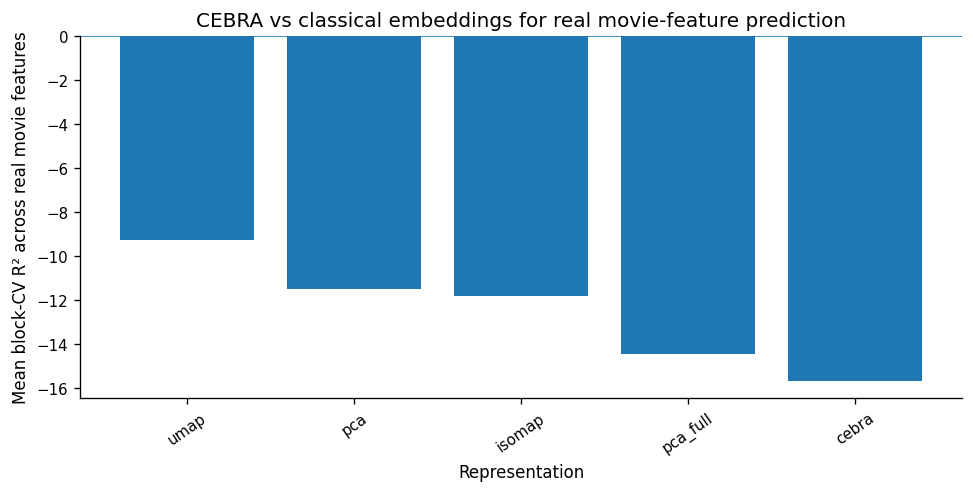

In [10]:
summary = (
    cebra_comparison
    .groupby("representation", as_index=False)
    .agg(
        mean_r2_across_targets=("mean_r2", "mean"),
        mean_spearman_across_targets=("mean_spearman_r", "mean"),
        n_targets=("target", "nunique"),
    )
    .sort_values("mean_r2_across_targets", ascending=False)
)

save_table(
    summary,
    paths.tables_dir / f"07_cebra_representation_summary_session_{session_id}.csv",
)

display(summary)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    summary["representation"],
    summary["mean_r2_across_targets"],
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Representation")
ax.set_ylabel("Mean block-CV R² across real movie features")
ax.set_title("CEBRA vs classical embeddings for real movie-feature prediction")
ax.tick_params(axis="x", rotation=35)

save_figure(
    fig,
    paths.figures_dir / "07_cebra_vs_classical_embedding_predictivity.png",
)

plt.show()

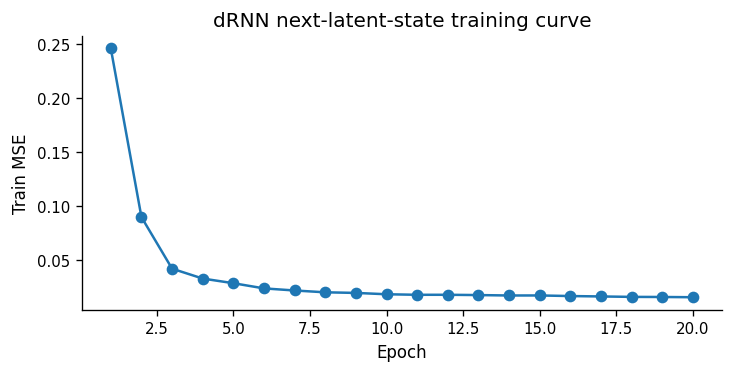

In [11]:
if cfg["advanced_models"].get("drnn_enabled", True):
    drnn_device = select_device(cfg["advanced_models"].get("device", "auto"))
    drnn = TorchDRNN(input_size=cebra_z.shape[1], hidden_size=cfg["advanced_models"]["hidden_size"], lr=cfg["advanced_models"]["learning_rate"], device=drnn_device)
    history = drnn.fit(cebra_z, sequence_length=cfg["advanced_models"]["sequence_length"], epochs=cfg["advanced_models"]["epochs"], batch_size=cfg["advanced_models"]["batch_size"])
    save_table(history, paths.tables_dir / f"07_drnn_training_history_session_{session_id}.csv")
    drnn.save(paths.models_dir / "checkpoints" / f"session_{session_id}_drnn.pt")
    preds = drnn.predict_next(cebra_z, sequence_length=cfg["advanced_models"]["sequence_length"])
    target = cebra_z[cfg["advanced_models"]["sequence_length"]:]
    metrics = regression_metrics(target, preds)
    save_table(pd.DataFrame([metrics]), paths.tables_dir / f"07_drnn_next_state_metrics_session_{session_id}.csv")
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(history["epoch"], history["train_mse"], marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train MSE")
    ax.set_title("dRNN next-latent-state training curve")
    save_figure(fig, paths.figures_dir / "07_drnn_training_curve.png")
    plt.show()
else:
    print("dRNN stage disabled in config.")

,model,n_samples,latent_dim,mse,rmse,mae,r2
1,persistence_baseline,870,3,0.015662,0.125146,0.082205,0.952929
0,dRNN,870,3,0.015880,0.126015,0.085401,0.952273
2,mean_state_baseline,870,3,0.333042,0.577098,0.501140,-0.000972


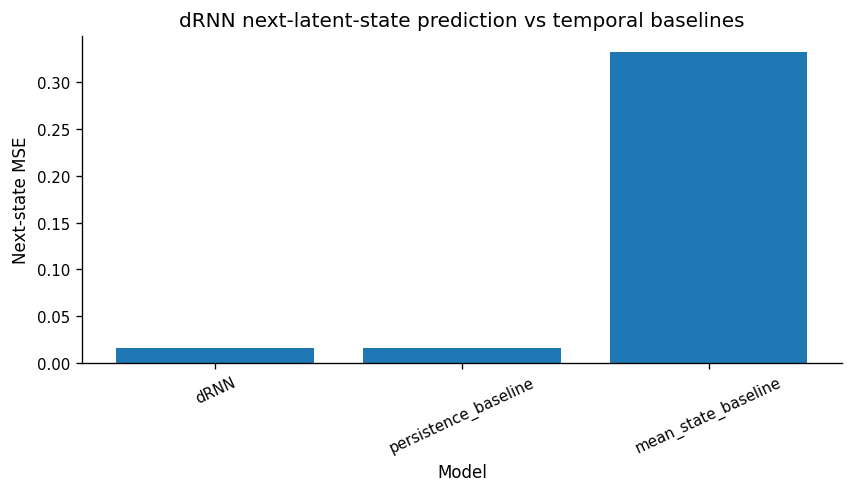

In [12]:
# ---------------------------------------------------------------------
# dRNN next-state evaluation against simple temporal baselines
# ---------------------------------------------------------------------
if cfg["advanced_models"].get("drnn_enabled", True):
    sequence_length = cfg["advanced_models"]["sequence_length"]

    # The dRNN predicts the next latent state after each input sequence.
    preds_drnn = drnn.predict_next(
        cebra_z,
        sequence_length=sequence_length,
    )

    target = cebra_z[sequence_length:]

    # Persistence baseline:
    # for each prediction target z[t], predict the immediately previous state z[t-1].
    preds_persistence = cebra_z[sequence_length - 1 : -1]

    # Mean-state baseline:
    # predict the average latent state from the available trajectory.
    mean_state = cebra_z[: -1].mean(axis=0, keepdims=True)
    preds_mean = np.repeat(mean_state, repeats=target.shape[0], axis=0)

    def next_state_metrics(y_true, y_pred, model_name):
        residual = y_true - y_pred
        mse = float(np.mean(residual ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(residual)))

        # Multi-output R² computed jointly across latent dimensions.
        ss_res = float(np.sum(residual ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean(axis=0, keepdims=True)) ** 2))
        r2 = float(1.0 - ss_res / (ss_tot + 1e-12))

        return {
            "model": model_name,
            "n_samples": int(y_true.shape[0]),
            "latent_dim": int(y_true.shape[1]),
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
        }

    drnn_eval = pd.DataFrame([
        next_state_metrics(target, preds_drnn, "dRNN"),
        next_state_metrics(target, preds_persistence, "persistence_baseline"),
        next_state_metrics(target, preds_mean, "mean_state_baseline"),
    ])

    save_table(
        drnn_eval,
        paths.tables_dir / f"07_drnn_next_state_baseline_comparison_session_{session_id}.csv",
    )

    display(drnn_eval.sort_values("mse"))

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        drnn_eval["model"],
        drnn_eval["mse"],
    )

    ax.set_xlabel("Model")
    ax.set_ylabel("Next-state MSE")
    ax.set_title("dRNN next-latent-state prediction vs temporal baselines")
    ax.tick_params(axis="x", rotation=25)

    save_figure(
        fig,
        paths.figures_dir / "07_drnn_next_state_baseline_comparison.png",
    )

    plt.show()